# Swiggy Restaurant Analysis
### Exploratory Data Analysis of Swiggy Restaurants across India
**Tools used:** Python, Pandas, Numpy, Matplotlib, Seaborn

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="darkgrid")
plt.rcParams['figure.figsize'] = (10, 6)

## 1. Load Data

In [3]:
df = pd.read_csv('swiggy_file.csv')
print("Shape:", df.shape)
df.head()

Shape: (140657, 10)


,Restaurant Name,Cuisine,Rating,Number of Ratings,Average Price,Number of Offers,Offer Name,Area,Pure Veg,Location
0,La Pino'Z Pizza,"Pizzas, Pastas",4.0,10+ ratings,₹250 for two,2,FLAT DEAL\nFLAT ₹125 OFF\nUSE FLAT125ABOVE ₹69...,LALA LAJPAT RAI MARKET,No,Abohar
1,The Second Wife,"Indian, North Indian",3.6,50+ ratings,₹250 for two,2,"30% OFF UPTO ₹75\nUSE TRYNEWABOVE ₹149, FLAT ₹...",Central Abohar,No,Abohar
2,Tasty Bites,"Italian, Beverages",3.8,10+ ratings,₹200 for two,1,FLAT ₹120 OFF\nUSE AXIS120ABOVE ₹500,Central Abohar,Yes,Abohar
3,Food Studio,"Pizzas, Burgers",3.5,8 ratings,₹49 for two,5,"50% OFF UPTO ₹100\nUSE TRYNEWABOVE ₹129, FLAT ...",Central Abohar,Yes,Abohar
4,Roll Express,"Fast Food, Snacks",4.3,100+ ratings,₹200 for two,2,DEAL OF DAY\n10% OFF UPTO ₹40\nUSE STEALDEALAB...,Circular Road,No,Abohar


## 2. Data Cleaning
Fixing Rating, Price, Number of Ratings columns and handling null values.

In [4]:
# Fix Rating
df['Rating'] = df['Rating'].replace(['NEW', '--'], np.nan)
df['Rating'] = df['Rating'].astype(float)

# Fix Average Price — remove ₹ and 'for two'
df['Average Price'] = df['Average Price'].str.replace('₹', '', regex=False)
df['Average Price'] = df['Average Price'].str.replace('for two', '', regex=False)
df['Average Price'] = df['Average Price'].str.strip().astype(int)

# Fix Number of Ratings — remove '+ ratings' text
df['Number of Ratings'] = df['Number of Ratings'].str.replace(' ratings', '', regex=False)
df['Number of Ratings'] = df['Number of Ratings'].str.replace('+', '', regex=False)
df['Number of Ratings'] = pd.to_numeric(df['Number of Ratings'], errors='coerce')

# Drop nulls in important columns
df.dropna(subset=['Cuisine', 'Area'], inplace=True)

print("Shape after cleaning:", df.shape)
print("\nNull values:\n", df.isnull().sum())

Shape after cleaning: (140628, 10)

Null values:
 Restaurant Name          0
Cuisine                  0
Rating               33692
Number of Ratings    52457
Average Price            0
Number of Offers         0
Offer Name            1800
Area                     0
Pure Veg                 0
Location                 0
dtype: int64


## 3. Filtering Bangalore Restaurants

In [5]:
# Filter Bangalore
bangalore = df[df['Location'] == 'Bangalore']
print("Total Bangalore restaurants:", len(bangalore))
print("\nTop Areas in Bangalore:")
print(bangalore['Area'].value_counts().head(10))


Total Bangalore restaurants: 1720

Top Areas in Bangalore:
Area
Jayanagar            223
Basavanagudi         189
Banashankari         150
Rajajinagar          124
Vijayanagar          103
Malleshwaram          86
Koramangala           77
Central Bangalore     76
Ashok Nagar           59
Majestic              36
Name: count, dtype: int64


## 4. Top Areas in Bangalore by Number of Restaurants

C:\Users\gayathri\AppData\Local\Temp\ipykernel_24672\1554374230.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_areas.values, y=top_areas.index, palette='Oranges_r')


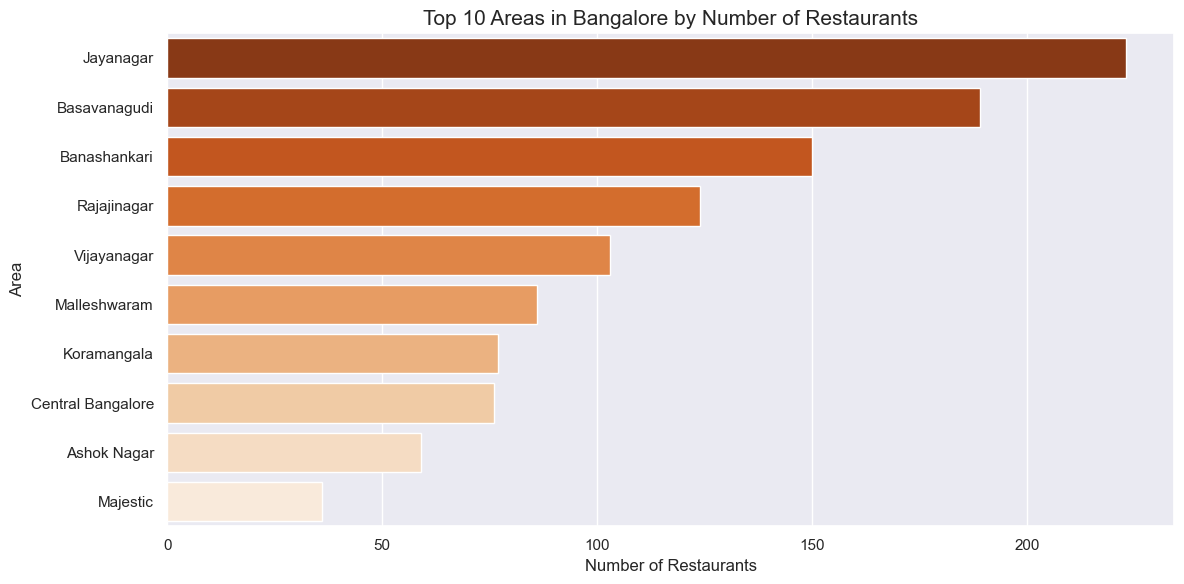

In [7]:
top_areas = bangalore['Area'].value_counts().head(10)

plt.figure(figsize=(12, 6))
sns.barplot(x=top_areas.values, y=top_areas.index, palette='Oranges_r')
plt.title('Top 10 Areas in Bangalore by Number of Restaurants', fontsize=15)
plt.xlabel('Number of Restaurants')
plt.ylabel('Area')
plt.tight_layout()
plt.show()

## 5. Top Cuisines in Bangalore

C:\Users\gayathri\AppData\Local\Temp\ipykernel_24672\759345866.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_cuisines.values, y=top_cuisines.index, palette='Blues_r')


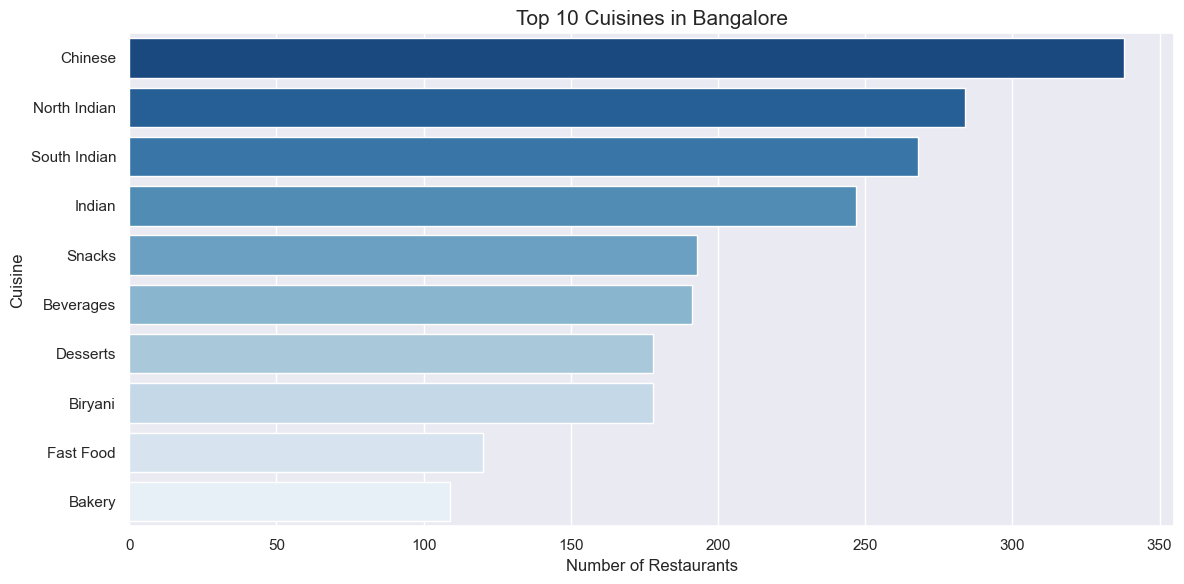

In [8]:
# Split cuisines (each restaurant has multiple cuisines separated by comma)
cuisines = bangalore['Cuisine'].str.split(', ').explode()
top_cuisines = cuisines.value_counts().head(10)

plt.figure(figsize=(12, 6))
sns.barplot(x=top_cuisines.values, y=top_cuisines.index, palette='Blues_r')
plt.title('Top 10 Cuisines in Bangalore', fontsize=15)
plt.xlabel('Number of Restaurants')
plt.ylabel('Cuisine')
plt.tight_layout()
plt.show()

## 6. Price vs Rating — Does Spending More Mean Better Food?

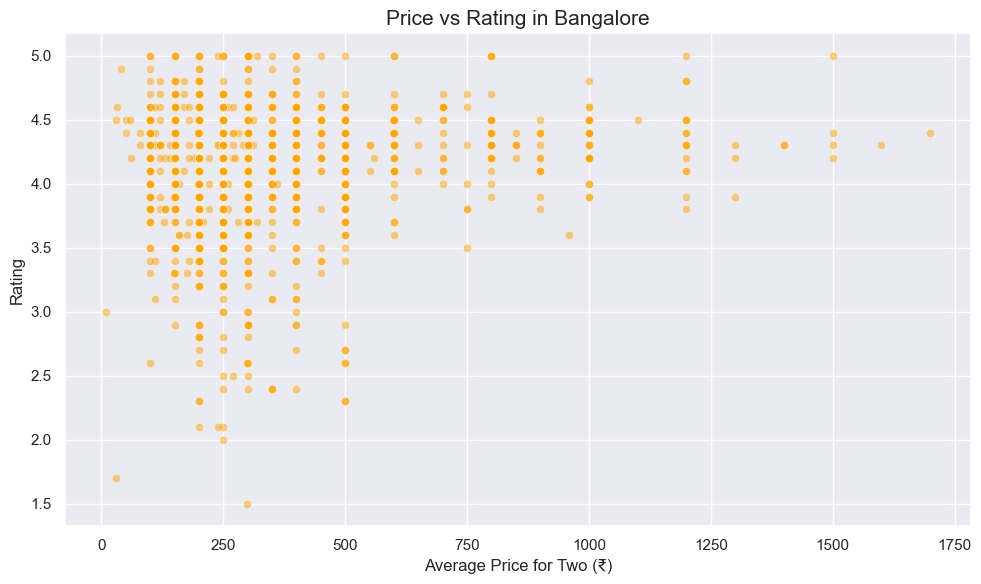

In [9]:
# Filter out null ratings
blr_rated = bangalore.dropna(subset=['Rating'])

plt.figure(figsize=(10, 6))
sns.scatterplot(data=blr_rated, x='Average Price', y='Rating', 
                alpha=0.5, color='orange')
plt.title('Price vs Rating in Bangalore', fontsize=15)
plt.xlabel('Average Price for Two (₹)')
plt.ylabel('Rating')
plt.tight_layout()
plt.show()

## 7. Pure Veg vs Non-Veg Restaurants in Bangalore

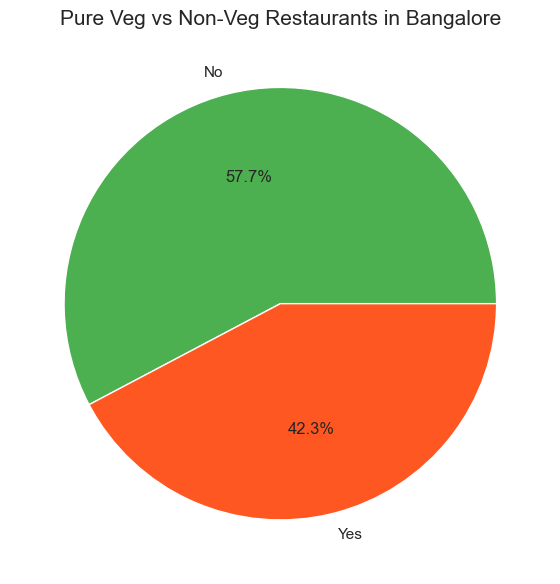

In [10]:
veg_counts = bangalore['Pure Veg'].value_counts()

plt.figure(figsize=(6, 6))
plt.pie(veg_counts.values, labels=veg_counts.index, 
        autopct='%1.1f%%', colors=['#4CAF50', '#FF5722'])
plt.title('Pure Veg vs Non-Veg Restaurants in Bangalore', fontsize=15)
plt.tight_layout()
plt.show()

## 8. Hidden Gems — High Rated & Affordable Restaurants in Bangalore

In [11]:
# Hidden gems — rating above 4.5 and price below 300
hidden_gems = bangalore[
    (bangalore['Rating'] >= 4.5) & 
    (bangalore['Average Price'] <= 300)
].dropna(subset=['Rating'])

hidden_gems_sorted = hidden_gems[['Restaurant Name', 'Area', 'Cuisine', 'Rating', 'Average Price']]\
    .sort_values('Rating', ascending=False).head(10)

print("Top Hidden Gem Restaurants in Bangalore:")
print(hidden_gems_sorted.to_string(index=False))

Top Hidden Gem Restaurants in Bangalore:
                      Restaurant Name                       Area                    Cuisine  Rating  Average Price
                 McCafe By McDonald'S                Basavangudi        Beverages, Desserts     5.0            250
                 R.M.K Scoops N Juice                Rajajinagar                     Juices     5.0            100
                          Eat 2 Treat                  Jayanagar             Snacks, Indian     5.0            150
                         O2 Juice Bar                  Jayanagar          Juices, Beverages     5.0            200
                          Bake Heaven                Koramangala                     Bakery     5.0            150
                     Royal Ice Corner               Basavanagudi        Desserts, Ice Cream     5.0            200
Cafe Levista - Coffee Chai And Snacks               Malleshwaram                  Beverages     5.0             99
                         Sugar Petals  

## 9. Rating Distribution of Bangalore Restaurants

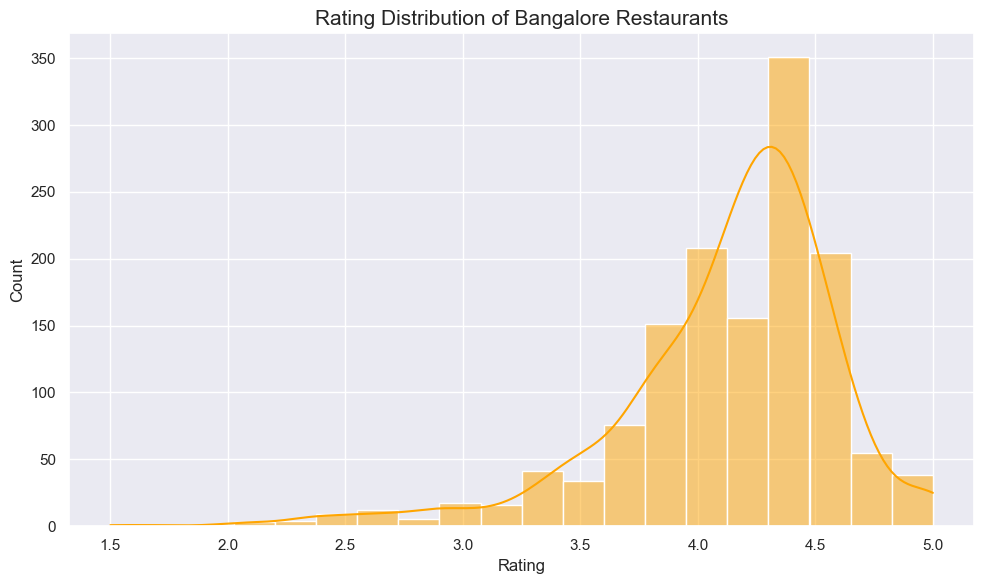

In [12]:
plt.figure(figsize=(10, 6))
sns.histplot(bangalore['Rating'].dropna(), bins=20, color='orange', kde=True)
plt.title('Rating Distribution of Bangalore Restaurants', fontsize=15)
plt.xlabel('Rating')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

## 10. Key Insights

1. **Jayanagar** has the most restaurants in Bangalore, followed by Basavanagudi and Banashankari.
2. **Chinese cuisine** is the most popular in Bangalore, reflecting the love for Indo-Chinese food.
3. **Mid-range priced restaurants** tend to have higher ratings — value for money matters more than premium pricing.
4. Bangalore has more **Pure Veg restaurants (57%)** than Non-Veg (42%), reflecting South Indian food culture.
5. **Hidden gems** like juice bars and small cafes in Jayanagar and Basavanagudi achieve perfect 5.0 ratings at under ₹300.
6. Most restaurants are rated around **4.4**, indicating high overall food quality in Bangalore.

## 11. Average Rating by Area in Bangalore

C:\Users\gayathri\AppData\Local\Temp\ipykernel_24672\3226358697.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=area_rating.values, y=area_rating.index, palette='Greens_r')


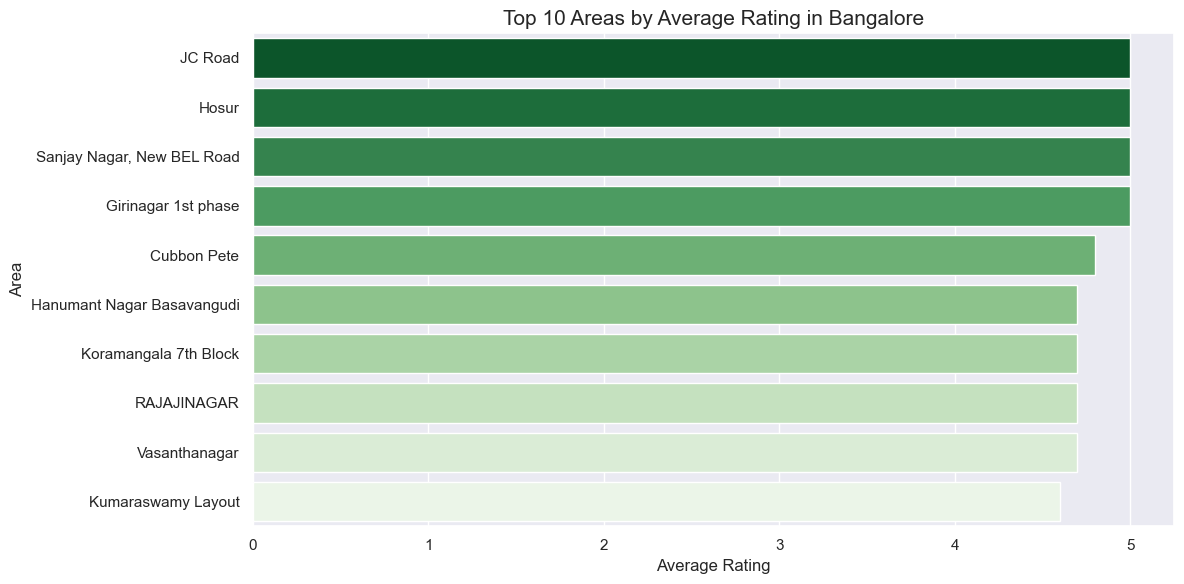

In [14]:
area_rating = bangalore.groupby('Area')['Rating'].mean().dropna()\
    .sort_values(ascending=False).head(10)

plt.figure(figsize=(12, 6))
sns.barplot(x=area_rating.values, y=area_rating.index, palette='Greens_r')
plt.title('Top 10 Areas by Average Rating in Bangalore', fontsize=15)
plt.xlabel('Average Rating')
plt.ylabel('Area')
plt.tight_layout()
plt.show()

## 12. ML Model — Predicting High Rated Restaurants

In [15]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report

# Prepare data
ml_data = bangalore.dropna(subset=['Rating', 'Average Price', 'Number of Ratings'])

# Target — 1 if rating >= 4.0, else 0
ml_data = ml_data.copy()
ml_data['High Rated'] = (ml_data['Rating'] >= 4.0).astype(int)

# Features
X = ml_data[['Average Price', 'Number of Ratings', 'Number of Offers']]
y = ml_data['High Rated']

# Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Model
model = RandomForestClassifier(random_state=42)
model.fit(X_train, y_train)

# Evaluate
y_pred = model.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.6699507389162561

Classification Report:
               precision    recall  f1-score   support

           0       0.44      0.29      0.35        62
           1       0.73      0.84      0.78       141

    accuracy                           0.67       203
   macro avg       0.58      0.56      0.56       203
weighted avg       0.64      0.67      0.65       203



## 13. Conclusion

This analysis of Swiggy Bangalore restaurants revealed that:
- Jayanagar is the most restaurant-dense area
- Chinese cuisine dominates Bangalore's food scene
- Mid-range restaurants offer the best value and ratings
- Bangalore has a strong vegetarian food culture
- Hidden gems exist in lesser known areas with perfect ratings at affordable prices
- A Random Forest model predicted high-rated restaurants with 67% accuracy

**Tools Used:** Python, Pandas, Numpy, Matplotlib, Seaborn, Scikit-learn